## **Genetický algoritmus - binární problém**

Genetický algoritmus je stochastická optimalizační metoda inspirovaná Darwinovou teorií přirozeného výběru a biologickou evolucí. Namísto deterministického procházení stavového prostoru udržuje populaci potenciálních řešení, která se iterativně vyvíjí v čase pomocí základních evolučních mechanismů:

* **Reprezentace jedince:** Řešení je zakódováno jako binární řetězec pevné délky $D$ (složený z bitů $0$ a $1$).
* **Evaluace jedince (Fitness)**: Každý jedinec je ohodnocen účelovou funkcí, která kvantifikuje jeho kvalitu v kontextu řešeného problému.
* **Elitismus:** Pevný zlomek nejlepších jedinců je beze změny přenesen přímo do nové generace, což garantuje monotónní neklesající kvalitu nejlepšího nalezeného řešení v čase.
* **Selekce:** Preferenční výběr rodičů na základě jejich zdatnosti (pomocí ruletové nebo pořadové selekce). Vyšší zdatnost znamená větší šanci předat genetickou informaci dalším generacím.
* **Křížení (Crossover):** Výměna bloků bitů mezi dvěma vybranými rodiči za účelem kombinace perspektivních jedinců.
* **Mutace:** Náhodná inverze bitů s malou pravděpodobností. Slouží k udržení genetické diverzity a brání uváznutí v lokálních optimech.

Cílem tohoto úkolu je genetický algoritmus vytvořit a poté prozkoumat dynamiku konvergence a vliv nastavení hyperparametrů na dvou odlišných binárních testovacích funkcích:
* **One-Max:** Lineární, plně separabilní problém se stabilním gradientem.
* **Leading Ones:** Nelineární problém se silnou epistatickou vazbou (bity za první nulou nenesou žádnou informaci).

Obě úlohy budou řešeny pro dimenze 10D, 30D a 100D s omezeným rozpočtem $100 \times D$ evaluací účelové funkce, přičemž výsledky budou vyhodnoceny napříč 10 nezávislými běhy.

### **Import potřebných knihoven**

In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

### **Konfigurace prostředí a pomocná funkce pro zobrazení výsledků**

V úvodní buňce jsou nastaveny základní parametry běhu experimentu a je definována pomocná funkce pro generování tabulky s výsledky úlohy.

* **Determinismus (Seed):** Inicializace generátorů náhodných čísel (`random` i `numpy`) zajišťuje plnou reprodukovatelnost všech měření.
* **Výchozí hyperparametry:**
  * `POPULATION_SIZE`: Velikost populace udržuje vyvážený kompromis mezi diverzitou a výpočetní náročností.
  * `ELITISM_RATE`: Zachování 15 % nejlepších jedinců zabraňuje ztrátě průběžných dosažených optim v dalších generacích.
  * `MUTATION_RATE`: Pravděpodobnost mutace (1 %) na každý jednotlivý bit.
* **Formátování statistik (`generate_markdown_table`):** Funkce převádí data z 10 nezávislých běhů (nejlepší výsledek, nejhorší výsledek, ...) do výsledné tabulky pro přehledné zobrazení.

In [2]:
np.random.seed(42)
random.seed(42)

POPULATION_SIZE = 50
ELITISM_RATE = 0.15     # 15 %
MUTATION_RATE = 0.01    # 1 %

def generate_markdown_table(stats_dict, problem_name):
    md = f"#### **Výsledky {problem_name} experimentu**\n\n"
    md += "| Dimenze | Počet evaluací | Nejlepší výsledek | Nejhorší výsledek | Průměr | Medián | Směrodatná odchylka | Úspěšnost nalezení optima |\n"
    md += "| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |\n"

    for dim, s in stats_dict.items():
        success_rate = f"{(s['success_count'] / s['runs']) * 100:.1f}%"
        
        md += (
            f"| **{dim}D** | {s['max_evals']} | {s['best']:.2f} | {s['worst']:.2f} | "
            f"{s['mean']:.2f} | {s['median']:.2f} | {s['std']:.2f} | {success_rate} |\n"
        )
    return md

### **Definice účelových (fitness) funkcí**

V této buňce jsou definovány dvě testovací optimalizační úlohy nad binárními řetězci:

* **One-Max problém (`fitness_onemax`):**
  * Spočívá v prostém součtu všech jedniček v binárním řetězci.
  * Jde o aditivní, lineární problém – každá přidaná jednička přímočaře zvyšuje zdatnost jedince bez ohledu na její pozici.
  * Globální optimum pro dimenzi *D* je hodnota *D*.

* **Leading Ones problém (`fitness_leading_ones`):**
  * Měří délku souvislé řady jedniček začínající od prvního bitu zleva (až k první nalezené nule).
  * Reprezentuje nelineární problém – bity za první nulou nemají na fitness žádný vliv, dokud není tato nula opravena na jedničku.
  * Globální optimum pro dimenzi *D* je rovněž hodnota *D*.

In [3]:
def fitness_onemax(binary_string):
    # Number of 1s in binary string
    return np.sum(binary_string)

def fitness_leading_ones(binary_string):
    # Length of leading streak of 1s from the left
    zeros = np.where(binary_string == 0)[0]
    if len(zeros) == 0:
        return len(binary_string)
    return zeros[0]

### **Genetické operátory (selekce, křížení, mutace)**

V této buňce jsou implemenovány základní operátory evolučního cyklu:

* **Selekce rodičů:**
  * **Ruletová selekce (`roulette_selection`):** Pravděpodobnost výběru je přímo úměrná absolutní hodnotě fitness. Může vést k předčasné konvergenci, pokud jeden jedinec výrazně převyšuje ostatní, nebo naopak ke ztrátě selekčního tlaku v závěru evoluce, kdy mají všichni jedinci téměř stejnou zdatnost.
  * **Pořadová selekce (`rank_selection`):** Jedinci jsou seřazeni a pravděpodobnost výběru závisí pouze na jejich relativním pořadí (ranku), nikoliv na absolutní hodnotě zdatnosti. Udržuje stabilní selekční tlak napříč všemi generacemi.

* **Jednobodové křížení (`single_point_crossover`):**
  * Náhodně zvolí bod řezu uvnitř binárního řetězce (s garancí alespoň jednoho bitu z každé strany).
  * Výměnou odpovídajících částí mezi dvěma rodiči vznikají dva noví potomci.

* **Jednobodová bitová mutace (`mutate`):**
  * Prochází binární řetězec bit po bitu a s pravděpodobností `mutation_rate` provede negaci hodnoty (0 $\to$ 1, 1 $\to$ 0).
  * Umožňuje prozkoumávat nové oblasti stavového prostoru a navracet ztracenou genetickou diverzitu.

In [4]:
def roulette_selection(population, fitness_scores):
    # Probability proportional to raw fitness
    total_fitness = np.sum(fitness_scores)
    if total_fitness == 0:
        probabilities = np.ones(len(fitness_scores)) / len(fitness_scores)
    else:
        probabilities = fitness_scores / total_fitness

    # Select two parent indexes based on roulette probabilities
    idx = np.random.choice(len(population), size=2, p=probabilities)
    return population[idx[0]], population[idx[1]]


def rank_selection(population, fitness_scores):
    # Sort individuals by fitness (ranks from 1 to N)
    order = np.argsort(fitness_scores)
    ranks = np.empty_like(order)
    ranks[order] = np.arange(1, len(fitness_scores) + 1)

    # Selection probability based on rank
    probs = ranks / np.sum(ranks)
    idx = np.random.choice(len(population), size=2, p=probs)
    return population[idx[0]], population[idx[1]]


def single_point_crossover(parent1, parent2):
    length = len(parent1)
    # Choose crossover point (ensure at least 1 gene from each side)
    cut = np.random.randint(1, length)

    # Create two children
    offspring1 = np.concatenate((parent1[:cut], parent2[cut:]))
    offspring2 = np.concatenate((parent2[:cut], parent1[cut:]))
    return offspring1, offspring2


def mutate(binary_string, mutation_rate):
    # Generate boolean mask where mutation occurs
    mask = np.random.rand(len(binary_string)) < mutation_rate
    # Invert bits where mask is True (1 - bit flips 0->1 and 1->0)
    mutated = binary_string.copy()
    mutated[mask] = 1 - mutated[mask]
    return mutated

### **Jádro algoritmu a jednotlivých experimentů**

Tato buňka obsahuje samotné jádro genetického algoritmu a funkci pro jednotné spouštění experimentů:

* **Implementace algoritmu (`run_genetic_algorithm`):**
  * **Limit evaluací (`max_evals`):** Namísto fixního počtu generací je algoritmus ukončen po vyčerpání daného počtu volání fitness funkce (100 $\times$ D).
  * **Elitismus:** Elitní jedinci jsou zkopírováni do nové populace spolu se svými hodnotami fitness, což šetří evaluace výhradně pro nové potomky.
  * **Inkrementální logování průběhu:** Po každém jednotlivém vyhodnocení potomka se zaznamenává aktuální globální maximum, což umožňuje sestavit křivku konvergence.

* **Spuštění experimentu (`run_experiment`):**
  * Provádí 10 nezávislých běhů pro každou testovanou dimenzi (D $\in$ {10, 30, 100}).
  * Zaznamenává a agreguje metriky kvality řešení: nejlepší, nejhorší, průměrnou hodnotu, medián, směrodatnou odchylku a procento běhů, které nalezly globální optimum *D*.
  * Počítá průměrnou konvergenční křivku napříč všemi 10 běhy v závislosti na počtu evaluací.

In [5]:
def run_genetic_algorithm(
    dimension,
    fitness_func,
    max_evals,
    pop_size=POPULATION_SIZE,
    elitism_rate=ELITISM_RATE,
    mutation_rate=MUTATION_RATE,
    selection="rank",
):

    select_fn = rank_selection if selection == "rank" else roulette_selection

    # Initialize random population
    population = np.random.randint(0, 2, size=(pop_size, dimension))
    fitness_scores = np.array([fitness_func(individual) for individual in population])

    evals_count = pop_size
    current_best = np.max(fitness_scores)

    # History of best fitness after each fitness evaluation
    eval_history = [current_best] * pop_size
    num_elites = max(1, int(elitism_rate * pop_size))

    while evals_count < max_evals:
        # 1. Elitism: Keep only the top individuals
        elite_indices = np.argsort(fitness_scores)[-num_elites:]
        new_population = [population[i].copy() for i in elite_indices]
        new_fitnesses = [fitness_scores[i] for i in elite_indices]

        # 2. Reproduction
        while len(new_population) < pop_size and evals_count < max_evals:
            # 2a. Parent selection
            p1, p2 = select_fn(population, fitness_scores)

            # 2b. Parent crossover
            c1, c2 = single_point_crossover(p1, p2)
            

            # 2c. Children mutation
            c1 = mutate(c1, mutation_rate)
            c2 = mutate(c2, mutation_rate)

            # Evaluate child 1
            f1 = fitness_func(c1)
            new_population.append(c1)
            new_fitnesses.append(f1)
            evals_count += 1
            current_best = max(current_best, f1)
            eval_history.append(current_best)

            # Evaluate child 2 if limit not reached
            if len(new_population) < pop_size and evals_count < max_evals:
                f2 = fitness_func(c2)
                new_population.append(c2)
                new_fitnesses.append(f2)
                evals_count += 1
                current_best = max(current_best, f2)
                eval_history.append(current_best)

        population = np.array(new_population[:pop_size])
        fitness_scores = np.array(new_fitnesses[:pop_size])

    return current_best, np.array(eval_history[:max_evals])


def run_experiment(problem_name, fitness_func, configs):
    all_stats = {}
    curves_per_dim = {}

    for dim, cfg in configs.items():
        max_evals = 100 * dim
        runs = 10
        final_bests = []
        histories = []

        for _ in range(runs):
            best_val, hist = run_genetic_algorithm(
                dimension=dim,
                fitness_func=fitness_func,
                max_evals=max_evals,
                pop_size=cfg.get("pop_size", POPULATION_SIZE),
                elitism_rate=cfg.get("elitism_rate", ELITISM_RATE),
                mutation_rate=cfg.get("mutation_rate", MUTATION_RATE),
                selection=cfg.get("selection", "rank"),
            )
            final_bests.append(best_val)
            histories.append(hist)

        curves_per_dim[dim] = np.mean(histories, axis=0)
        all_stats[dim] = {
            "max_evals": max_evals,
            "runs": runs,
            "best": np.max(final_bests),
            "worst": np.min(final_bests),
            "mean": np.mean(final_bests),
            "median": np.median(final_bests),
            "std": np.std(final_bests),
            "success_count": np.sum(np.array(final_bests) == dim),
        }

    return all_stats, curves_per_dim

### **One-Max problém**

V této buňce se spouští optimalizace One-Max problému pro dimenze 10, 30 a 100 s rozpočtem 100 $\times$ D evaluací (1 000, 3 000 a 10 000).

* **Nastavení hyperparametrů:**
  * **Velikost populace (`pop_size`):** Škáluje se od 20 (pro 10D) po 80 (pro 100D). Větší populace u vyšších dimenzí udržuje dostatečnou variabilitu.
  * **Elitismus (`elitism_rate = 0.10`):** 10 % nejlepších jedinců bezpečně chrání nalezená řešení před destruktivním vlivem křížení a mutace.
  * **Mutace (`mutation_rate = 0.01`):** Stabilní 1 % pravděpodobnost bitové mutace poskytuje ideální poměr mezi prozkoumáváním (exploration) a vytěžováním (exploitation) prostoru řešení.
  * **Selekce (`selection = "rank"`):** Pořadová selekce zaručuje konstantní selekční tlak i v závěrečných fázích, kdy většina populace dosahuje vysoké fitness.

* **Výstupy:**
  * Souhrnná tabulka se statistikami z 10 nezávislých běhů.
  * Průměrná konvergenční křivka zachycující nárůst hodnoty fitness v závislosti na počtu evaluací.

#### **Výsledky One-Max experimentu**

| Dimenze | Počet evaluací | Nejlepší výsledek | Nejhorší výsledek | Průměr | Medián | Směrodatná odchylka | Úspěšnost nalezení optima |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **10D** | 1000 | 10.00 | 10.00 | 10.00 | 10.00 | 0.00 | 100.0% |
| **30D** | 3000 | 30.00 | 30.00 | 30.00 | 30.00 | 0.00 | 100.0% |
| **100D** | 10000 | 100.00 | 100.00 | 100.00 | 100.00 | 0.00 | 100.0% |


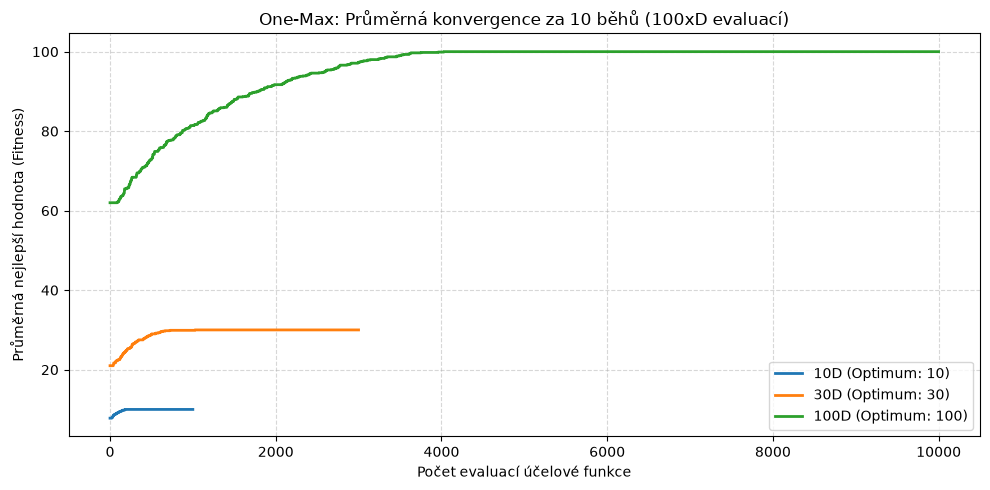

In [6]:
# Hyperparameter setup for One-Max
# One-Max has an additive gradient, standard parameters converge reliably
onemax_configs = {
    10: {
        "pop_size": 20,
        "elitism_rate": 0.10,
        "mutation_rate": 0.01,
        "selection": "rank",
    },
    30: {
        "pop_size": 40,
        "elitism_rate": 0.10,
        "mutation_rate": 0.01,
        "selection": "rank",
    },
    100: {
        "pop_size": 80,
        "elitism_rate": 0.10,
        "mutation_rate": 0.01,
        "selection": "rank",
    },
}

onemax_stats, onemax_curves = run_experiment(
    "One-Max", fitness_onemax, onemax_configs
)

display(Markdown(generate_markdown_table(onemax_stats, "One-Max")))

plt.figure(figsize=(10, 5))
for dim, curve in onemax_curves.items():
    plt.plot(curve, label=f"{dim}D (Optimum: {dim})", linewidth=2)

plt.title("One-Max: Průměrná konvergence za 10 běhů (100xD evaluací)")
plt.xlabel("Počet evaluací účelové funkce")
plt.ylabel("Průměrná nejlepší hodnota (Fitness)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### **Leading Ones problém**

V této buňce se testuje genetický algoritmus na nelineárním problému Leading Ones se stejným rozpočtem 100 $\times$ D evaluací (1 000, 3 000 a 10 000).

Na rozdíl od One-Max problému zde záleží na přesném pořadí bitů zleva. Bity nacházející se za první nulou nenesou žádnou okamžitou informaci o zdatnosti, což úlohu výrazně ztěžuje.

* **Nastavení hyperparametrů:**
  * **Zvýšený elitismus (`elitism_rate = 0.15 až 0.20`):** Vyšší podíl chráněných jedinců se ukázal jako klíčový pro zachování již nalezeného prefixu jedniček.
  * **Velikost populace:** Především u 100D řetězce jsem zjistil, že menší velikost populace může vést k lepším průměrným výsledkům algoritmu.
  * **Nízká pravděpodobnost mutace:** Nízká mutace snižuje riziko nechtěného překlopení prefixových bitů na nulu.

* **Výstupy:**
  * Souhrnná tabulka statistických metrik z 10 nezávislých běhů.
  * Průměrná konvergenční křivka ukazující postupné prodlužování levého prefixu jedniček.

#### **Výsledky Leading Ones experimentu**

| Dimenze | Počet evaluací | Nejlepší výsledek | Nejhorší výsledek | Průměr | Medián | Směrodatná odchylka | Úspěšnost nalezení optima |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **10D** | 1000 | 10.00 | 10.00 | 10.00 | 10.00 | 0.00 | 100.0% |
| **30D** | 3000 | 30.00 | 30.00 | 30.00 | 30.00 | 0.00 | 100.0% |
| **100D** | 10000 | 100.00 | 72.00 | 89.60 | 89.50 | 7.89 | 20.0% |


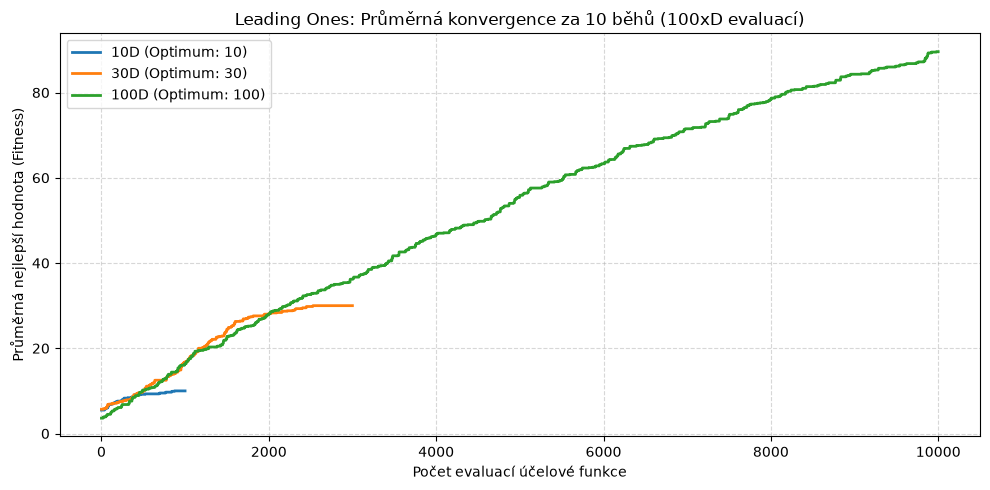

In [8]:
# Hyperparameter setup for Leading Ones
# Slightly smaller population with strong elitism (15-20%) preserves prefix discoveries.
leading_ones_configs = {
    10: {
        "pop_size": 30,
        "elitism_rate": 0.15,
        "mutation_rate": 0.0075,
        "selection": "rank",
    },
    30: {
        "pop_size": 20,
        "elitism_rate": 0.20,
        "mutation_rate": 0.01,
        "selection": "rank",
    },
    100: {
        "pop_size": 10,
        "elitism_rate": 0.20,
        "mutation_rate": 0.0075,
        "selection": "rank",
    },
}

lo_stats, lo_curves = run_experiment(
    "Leading Ones", fitness_leading_ones, leading_ones_configs
)

display(Markdown(generate_markdown_table(lo_stats, "Leading Ones")))

plt.figure(figsize=(10, 5))
for dim, curve in lo_curves.items():
    plt.plot(curve, label=f"{dim}D (Optimum: {dim})", linewidth=2)

plt.title("Leading Ones: Průměrná konvergence za 10 běhů (100xD evaluací)")
plt.xlabel("Počet evaluací účelové funkce")
plt.ylabel("Průměrná nejlepší hodnota (Fitness)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

## **Závěr a shrnutí úkolu**

Tento úkol demonstroval chování genetického algoritmu na dvou strukturálně odlišných binárních úlohách.

#### **Srovnání úloh: One-Max vs. Leading Ones**

##### **One-Max**
* Každý bit přispívá k celkové hodnotě fitness nezávisle. Algoritmus těží ze stabilního gradientu, kdy jakákoli náhodně nalezená jednička okamžitě zvyšuje fitness.
* Díky tomu jsem také dosáhl 100% úspěšnosti nalezení globálního optima ve všech zadaných dimenzích (10D, 30D i 100D)

##### **Leading Ones**
* Hodnotu fitness určuje nepřerušená řada jedniček z levé strany. Bity za první nulou nepředstavují žádnou odměnu.
* Zde byla optimalizace o dost náročnější, v dimenzi 100D jsem i přes různé nastavení hyperparametrů nedospěl k výsledku, kdy bych našel optimum ve více než 2 z 10 proběhlých nezávislých běhů.

#### **Vliv hyperparametrů**

##### **Velikost populace**
* Tento hyperparametr mě nějvíce zaskočil především při nastavení u dimenze 100D u Leading Ones problému. Zatímco u One-Max úlohy jsem s rostoucí dimenzí velikost populace zvětšoval, nejlepšího výsledku u dimenze 100D u Leading Ones jsem naopak dosáhl po zmenšení velikosti populace v daném experimentu.

##### **Elitismus**
* U One-Max optimalizace mi stačilo pro dosažení optima zachovat 10 % nejlepších jedinců z předchozí generaci. 
* U Leading-Ones optimalizace musela být hodnota elitismu větší (15 - 20 %), jelikož bylo v mém zájmu ponechat co nejvíce jedinců, kteří už měli vybudovaný dlouhý prefix jedniček.

##### **Míra mutace**
* Míru mutace jsem držel na hodnotě 1 % u One-Max problému, jelikož inverze bitu především z 0 na 1 byla velice žádoucí.
* U Leading Ones jsem hodnotu tohoto parametru snížil na 0,75 % u dimenzí 10D a 100D, což mi přineslo kvalitnější výsledky. Zde si naopak myslím, že ztráta hodnoty fitness funkce za inverzi bitu v již existujícím prefixu samých jedniček nepřevyšuje možnou odměnu za prodloužení tohoto prefixu, a tudíž je nastavení pravděpodobnosti mutace na menší procentuální hodnotu tou správnou variantou.



## **Autor úkolu**
* Martin Koňařík m1_konarik@utb.cz

*Vytvořeno v rámci předmětu AP9EV na FAI UTB v roce 2026*